# AlphaGenome Introductory Practical Session

Welcome to the AlphaGenome practical session! This notebook will guide you through the basics of using AlphaGenome for genomic data analysis.  
This is not a quick start-tutorial or meant to provide introduction to all of AlphaGenome's capabilities.  It is meant more as a playground and straw man to encourage group discussion.

For a more comprehensive walkthrough, please check out the [AlphaGenome Quick Start](https://colab.research.google.com/github/google-deepmind/alphagenome/blob/main/colabs/quick_start.ipynb)

## Key Takeaways: 
- The primary input to AlphaGenome is `genomic sequence` (...but also accepts: `genomic coordinates`, `context windows` such as gene models).
- AlphaGenome predicts the molecular consequences of DNA sequences; **not trait or disease causality**.
- It outputs functional genomics (gene regulatory) signals at base resolution, in the **limited context** (tissues/cells) on which it has been trained.
- _It is useful_ when a signal is **sequence-driven** and **generalizable** or when you care about **relative prioritization** (e.g., ranking variants).
- _It is not useful_ when biology is strongly **context-specific** and mismatched to the training.
- Don't treat outputs as **truth**; compare variants under the same context (relative ranking) or look for **consistent signals** (or _lack thereof_) across multiple predicted assays.

## 1. First Steps -> AlphaGenome API KEY

To use the model, you will need an [AlphaGenome API Key](https://deepmind.google.com/science/alphagenome). The `API key` needs to be provided to the model at load time.  If you have not yet done so, please follow the link to generate your `API Key`.  

Run the following cell to generate a user prompt and supply your key to the notebook.

In [ ]:
# prompt user for API KEY
from getpass import getpass

api_key = getpass("Enter your AlphaGenome API key: ")

## 2. Import `alphagenome` Python package

AlphaGenome provides an API client.  It is installed in this Jupyter environment so no need to do anything here, but for future reference, it is available in the `PyPI` repository, so can be installed with `pip` or according to the recommended method for a managed build environment (e.g., `conda`, `poetry`).

Run the following cell to import alphagenome client tools, pandas, and a couple visualization generators into this notebook.

In [ ]:
# Import libraries
from alphagenome.data.genome import Variant
from alphagenome.data import gene_annotation, genome, track_data, transcript
from alphagenome.interpretation import ism
from alphagenome.models import dna_client, variant_scorers
from alphagenome.visualization import plot_components
import matplotlib.pyplot as plt
import pandas as pd

# for displaying interactive tables
from itables import init_notebook_mode, show

init_notebook_mode(all_interactive=True)

## 3. Before we start - load model and auxiliary objects

### 3A. Initial Client / Load Moadel

To leverage the API client and "initialize" the model, you will need to provide your API Key.

In [7]:
# initalize the AlphaGenome API client w/the API KEY
dna_model = dna_client.create(api_key)

### 3B. Metadata objects for humans

For specific details on AlphaGenoeme outputs, please check out the [AlphaGenome Quick Start](https://colab.research.google.com/github/google-deepmind/alphagenome/blob/main/colabs/quick_start.ipynb).

AlphaGenome predicts molecular consequences by generating multiple assay-specific signal tracks, each conditioned on a particular biosample (cell/tissue) context.

Allowable output types are enumerated by `dna_client.OutputType`.  
Generated tracks can be filtered by tissue and cell lines by leveraging a limited set of terms from the UBERON and Cell Line (CL) ontologies.  

> **Important** Tracks can only be filtered for tissues/cells used to train the model (a selection of mainly ENCODE and FANTOM5 tracks). Not all predicted outputs are available for all biosample types. 

Allowable terms are accesible via the instantiated model's `output_metadata` for the organism of interest.

In [ ]:
# list all output types
print(f"Output types: {[output.name for output in dna_client.OutputType]}")

# generate table of output metadata (biosample type & assay type)
output_metadata = dna_model.output_metadata(
    organism=dna_client.Organism.HOMO_SAPIENS
).concatenate()
show(
    output_metadata, maxBytes="1MB"
)  # if your notebook is slow, reduce maxBytes to 8KB to truncate this table

Output types: ['ATAC', 'CAGE', 'DNASE', 'RNA_SEQ', 'CHIP_HISTONE', 'CHIP_TF', 'SPLICE_SITES', 'SPLICE_SITE_USAGE', 'SPLICE_JUNCTIONS', 'CONTACT_MAPS', 'PROCAP']


Loading ITables v2.7.3 from the init_notebook_mode cell... (need help?)


### 3B. Gene Annotations (from GENCODE)

Read in the GENCODE GTF file, filter for protein-coding genes and highly supported transcripts, then instantiate an extractor for identifying transcripts in a region of interest.

In [ ]:
# Load gene annotations (from GENCODE).
gtf = pd.read_feather(
    "https://storage.googleapis.com/alphagenome/reference/gencode/"
    "hg38/gencode.v46.annotation.gtf.gz.feather"
)

# Filter to protein-coding genes and highly supported transcripts.
gtf_transcript = gene_annotation.filter_transcript_support_level(
    gene_annotation.filter_protein_coding(gtf), ["1"]
)

# Extractor for identifying transcripts in a region.
transcript_extractor = transcript.TranscriptExtractor(gtf_transcript)

# Also define an extractor that fetches only the longest transcript per gene.
gtf_longest_transcript = gene_annotation.filter_to_longest_transcript(gtf_transcript)
longest_transcript_extractor = transcript.TranscriptExtractor(gtf_longest_transcript)

## 4. Let's Try it Out: Predict Variant Effects

The MS4A cluster is a very interesting region for AD.  
- There is a strong, replicated GWAS signal, making it one of the top non-APOE loci for late-onset AD. 
- Multiple independent variants show association across cohorts.  
- Signals are non-coding, but the regulatory effects are not fully understood.  
- But...
  - MS4A genes expression is very cell specific, significantly enriched in **microglia** relative to neurons.  
  - **AlphaGenome was not trained on microglia**. 

<img src="./images/bellenguez_manhattan.png" width="100%">


<img src="./images/MS4A_region.png" width="100%">

From Bellenguez et al. 2022 (Image source: [NIAGADS GenomicsDB](https://www.niagads.org/genomics/app/record/track/GCST90027158) / NIAGADS Genome Browser).

The remainder of this workbook will step through2  ways AlphaGenome can be used to predict variant effects and lend insight to regulatory impacts of non-coding variants.

In each of the examples, we are going to do the best we can with biological context:

* `brain tissue`: `UBERON:0000955`
* `macrophage`: `CL:0000235` (proxy for `microglia`; both dervive from myleoid lineage, shared TF drivers [SP1, IRFs, etc], similar functional role, some known regulatory overlap)

Example [4A](#4a-predict-variant-effects): Predict the effect of a variant 11:60254475:G:A on a specific output type and tissue by making predictions for the reference (REF) and alternative (ALT) allele sequence.

Example [4B](#4b-scoring-all-possible-snvs-in-a-specific-interval):  Score all possible SNVs in a specific interval to highlight which regions in a DNA sequence are functionally important for variant prediction.

## 4A. Predict variant effects - Gene expression

- 11:60254475:G:A

Gene expression is primarily captured by the model outputs RNA_SEQ and CAGE. 

Specify the variant (`Variant` object imported from `alphagenome.data.genome`) and define the interval over which to make the `REF/ALT` predictions and the targeted outputs.  The iterval is defined by "resizing" to a model-compatible sequence length.

In [28]:
BRAIN = "UBERON:0000955"
MACROPHAGE = "CL:0000235"

variant = Variant(
    chromosome="chr11",
    position=60254475,
    reference_bases="G",  # Can differ from the true reference genome base.
    alternate_bases="A",
)

interval = variant.reference_interval.resize(dna_client.SEQUENCE_LENGTH_1MB)

variant_output = dna_model.predict_variant(
    interval=interval,
    variant=variant,
    requested_outputs=[
        dna_client.OutputType.RNA_SEQ,
        dna_client.OutputType.CAGE,
    ],
    ontology_terms=[MACROPHAGE, BRAIN],
)

print(f"{variant_output}")

VariantOutput(reference=Output(atac=None, cage=TrackData(values=array([[6.7234039e-05, 8.6307526e-05, 5.6076050e-04, 9.6893311e-04],
       [1.3351440e-04, 1.9359589e-04, 2.1934509e-04, 3.5667419e-04],
       [6.7234039e-05, 9.1552734e-05, 5.6076050e-04, 9.6893311e-04],
       ...,
       [4.9591064e-04, 5.9509277e-04, 1.9264221e-04, 1.9073486e-04],
       [5.3024292e-04, 6.3705444e-04, 2.0599365e-04, 2.1553040e-04],
       [7.7056885e-04, 9.1934204e-04, 4.3678284e-04, 5.1879883e-04]],
      shape=(1048576, 4), dtype=float32), metadata=                   name strand Assay title  ontology_curie biosample_name  \
0      hCAGE CL:0000235      +       hCAGE      CL:0000235     macrophage   
1  hCAGE UBERON:0000955      +       hCAGE  UBERON:0000955          brain   
2      hCAGE CL:0000235      -       hCAGE      CL:0000235     macrophage   
3  hCAGE UBERON:0000955      -       hCAGE  UBERON:0000955          brain   

  biosample_type data_source  nonzero_mean  
0   primary_cell      fanto

Let's plot the results to be able to better inspect & explore.  

Build the plot by constructing multiple tracks (`components`).  

> See AlphaGenome's [visualization guide](https://www.alphagenomedocs.com/visualization_library_basics.html#visualization-basics) for more information.

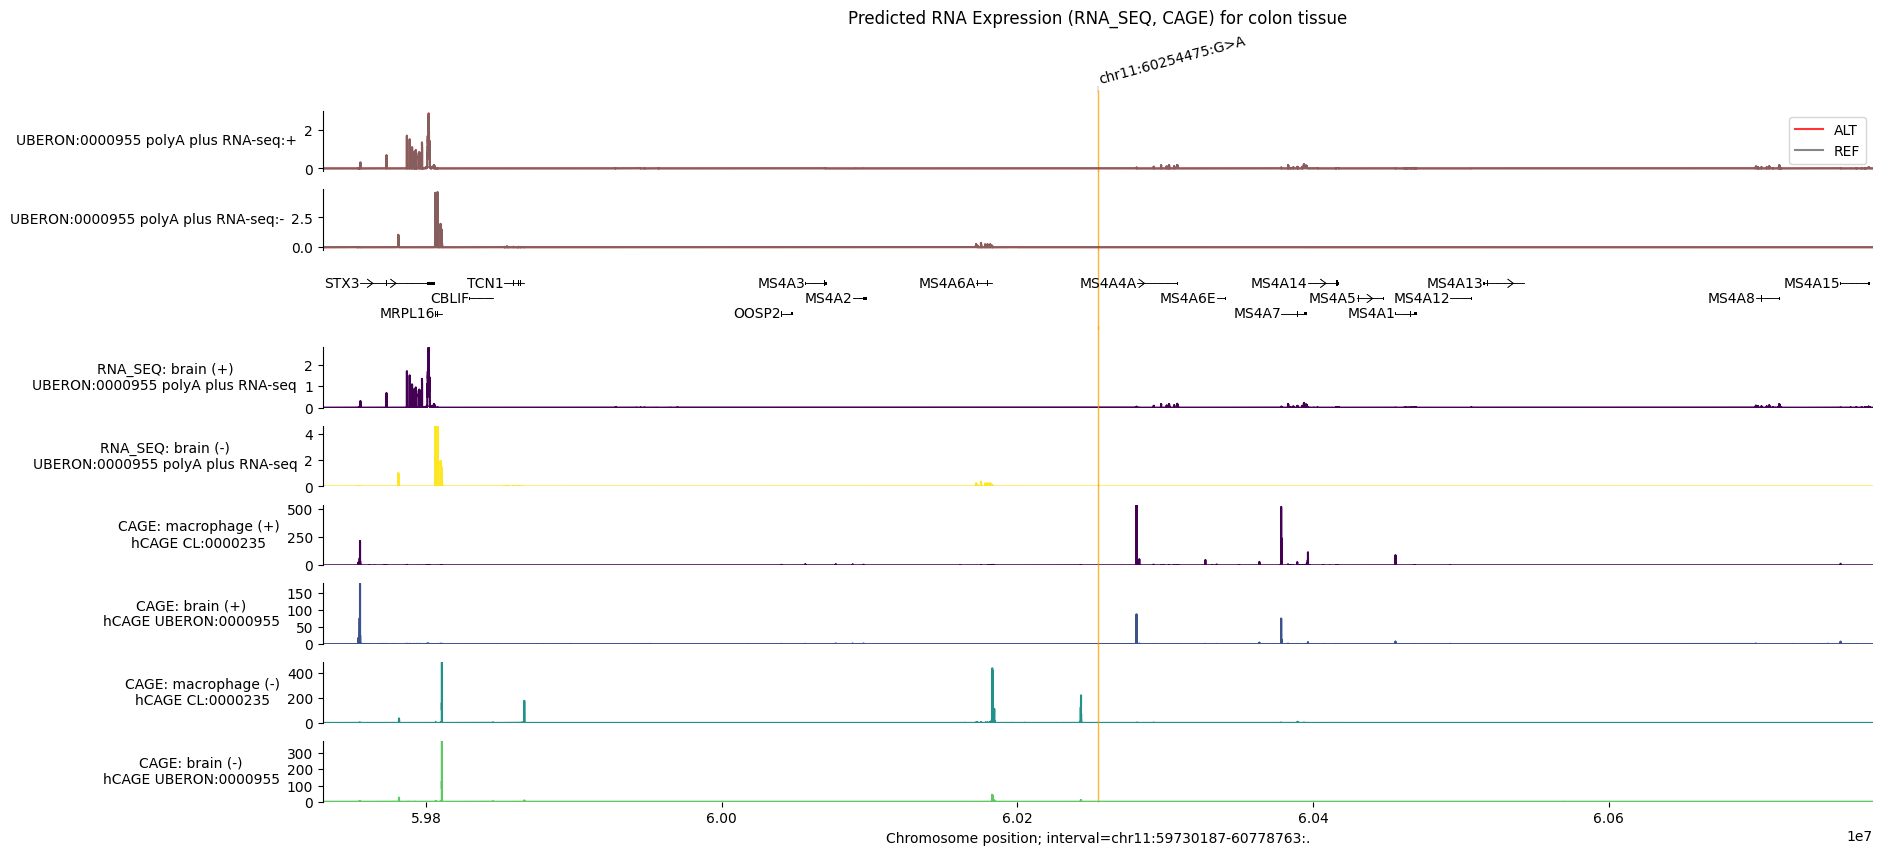

In [ ]:
transcripts = transcript_extractor.extract(interval=interval)
# Extract the longest transcripts per gene for this interval.
longest_transcripts = longest_transcript_extractor.extract(interval)


plot = plot_components.plot(
    [
        plot_components.OverlaidTracks(
            tdata={
                "REF": variant_output.reference.rna_seq,
                "ALT": variant_output.alternate.rna_seq,
            },
            colors={"REF": "dimgrey", "ALT": "red"},
        ),
        plot_components.TranscriptAnnotation(longest_transcripts),
        plot_components.Tracks(
            tdata=variant_output.reference.rna_seq,
            ylabel_template="RNA_SEQ: {biosample_name} ({strand})\n{name}",
        ),
        plot_components.Tracks(
            tdata=variant_output.reference.cage,
            ylabel_template="CAGE: {biosample_name} ({strand})\n{name}",
        ),
    ],
    # Annotate the location of the variant as a vertical line.
    annotations=[plot_components.VariantAnnotation([variant], alpha=0.8)],
    interval=interval,
    title="Predicted RNA Expression (RNA_SEQ, CAGE) for colon tissue",
)

### 4B. Scoring all possible SNVs in a specific interval 

to highlight which regions in a DNA sequence are functionally important for variant prediction.